In [ ]:

using Revise
using PVlib

using HTTP
using JSON
using DataFrames
using Dates
using CSV
using Plots
using Statistics
using LinearAlgebra
using TimeZones

using ForwardDiff
using FiniteDiff

In [2]:
motion = 0.2*ones(1, 6);

tilt, azimuth = panel_tilt_azimuth(motion);

println(isapprox(tilt[1], 16.15129532916803; atol=1e-6))

println(isapprox(azimuth[1], 124.11762388541732; atol=1e-6))

albedo = get_ocean_surface_albedo(800.0, 30.0, 180.0);

isapprox(albedo, 0.033189; atol=1e-3)

true
true


true

In [3]:
total_irradiance = [
    TotalIrradiance(
        ZonedDateTime(2023, 1, 1, tz"America/Denver"),
        1000.0, 0.0, 0.0, 0.0, 0.0
    )
    TotalIrradiance(
        ZonedDateTime(2023, 1, 2, tz"America/Denver"),
        1000.0, 0.0, 0.0, 0.0, 0.0
    )
]

weather_data = WeatherSample{Float64}(
        ZonedDateTime(2023, 1, 1, tz"America/Denver"),
        1.0, 1.0, 1.0,               # ghi, dni, dhi (unused here)
        25.0,                        # temp_air (C)
        1.0,                         # relative_humidity (unused here)
        20.0,                     # temp_dewpoint (unused here)
        101325.0,                    # pressure (unused here)
        1.0,                         # wind_speed (m/s)
        1.0,                          # wind_direction (unused here)
        0.1,                     # albedo (unused here)
    );

cell_temperature = rolling_average_sapm_cell_temperature(total_irradiance, weather_data);
println(cell_temperature[1].cell_temperature)
println(isapprox(cell_temperature[1].cell_temperature,  57.3225; atol=1e-3))


57.322504092500964
true


In [4]:
panel = Panel(2.0, 1.0);

obstacle = BoxObstacle(-1.0, 1.0, -0.1, 0.1, 0.3, 0.4);

solar_pos = SolarPosition(
           ZonedDateTime(2020, 6, 1, 12, 0, 0, tz"UTC"),
           30.0,   # apparent_zenith
           30.0,   # zenith
           60.0,   # apparent_elevation
           60.0,   # elevation
           180.0,  # azimuth
           1.0,    # equation_of_time
       );

fshade = get_shaded_fraction(solar_pos, 20.0, 180.0, panel, obstacle);

println(fshade)
isapprox(fshade, 0.199933; atol=1e-3)

0.1999330684315968


true

In [5]:
total_irradiance = TotalIrradiance(
           ZonedDateTime(2023, 1, 1, tz"America/Denver"),
           1000.0, 800.0, 500.0, 200.0, 0.0
       );

power_norm = get_power_norm(total_irradiance, 0.0, 9);

println(power_norm)

println(isapprox(power_norm, 1.0; atol=1e-4))

0.9999925274424175
true


In [6]:
power_norm = 0.9

pv_module = read_solar_module("Canadian Solar CS5P-220M [ 2009]");

effective_irradiance = EffectiveIrradiance(ZonedDateTime(2023, 1, 1, tz"America/Denver"), 800);  # effective irradiance (W/m^2)

cell_temp = CellTemperature(ZonedDateTime(2023, 1, 1, tz"America/Denver"), 25);   # cell temperature (C)

dc_unshaded = sapm_dc_components(
           pv_module,
           effective_irradiance,
           cell_temp
       )

dc_shaded = sapm_dc_components_shaded(
           pv_module,
           effective_irradiance,
           cell_temp,
           power_norm
       )

println(isapprox(dc_shaded.p_mp, dc_unshaded.p_mp * power_norm))


true


In [7]:
dc_power = DCComponents(
           ZonedDateTime(2023, 1, 1, tz"America/Denver"),
           5.0, # i_sc (A)
           2.0, # i_mp (A)
           12.0, # v_oc (V)
           10.0, # v_mp (V)
           20.0, # p_mp (W)
           nothing, # i_x (A)
           nothing, # v_x (V)
       );

pv_inverter = read_solar_inverter("ABB: MICRO-0.25-I-OUTD-US-208 [208V]");

ac_power = sandia_ac_power(pv_inverter, dc_power);

isapprox(ac_power.ac_power, 17.615580191975287; atol=1e-6)


true

In [8]:
pv_inverter = read_solar_inverter("ABB: MICRO-0.25-I-OUTD-US-208 [208V]");

cols = [:name,:vac,:pso,:paco,:pdco,:vdco,:c0,:c1,:c2,:c3,:pnt,:vdcmax,:idcmax,:mppt_low,:mppt_high,:cec_date,:cec_type];

println(fieldnames(typeof(pv_inverter)))
println(fieldnames(typeof(pv_inverter)) == Tuple(cols))
println(pv_inverter)

pv_inverter.pdco

(:name, :vac, :pso, :paco, :pdco, :vdco, :c0, :c1, :c2, :c3, :pnt, :vdcmax, :idcmax, :mppt_low, :mppt_high, :cec_date, :cec_type)
true
SolarInverter
────────────
name       │ ABB: MICRO-0.25-I-OUTD-US-208 [208V]
vac        │ 208.0
pso        │ 2.089607
paco       │ 250.0
pdco       │ 259.588593
vdco       │ 40.0
c0         │ -4.1e-5
c1         │ -9.1e-5
c2         │ 0.000494
c3         │ -0.013171
pnt        │ 0.075
vdcmax     │ 50.0
idcmax     │ 6.489715
mppt_low   │ 30.0
mppt_high  │ 50.0
cec_date   │ n/a
cec_type   │ Utility Interactive



259.588593

In [9]:
latitude = 35.1
longitude = -106.6
altitude = 1500.0 # m

start_date = Date(2023, 1, 1)
end_date = Date(2023, 1, 1)
tz = TimeZone("America/Denver")

number_of_panels = 1
surface_tilt = latitude
surface_azimuth = 180.0

180.0

In [10]:


weather_data = WeatherSample(
           ZonedDateTime(2020, 6, 1, 12, 0, 0, tz"UTC"),
           800.0,       # ghi
           100.0,       # dhi
           900.0,       # dni
           25.0,        # temp_air
           50.0,        # relative_humidity
           20.0,        # temp_dewpoint
           101325.0,    # pressure
           5.0,         # wind_speed
           180.0,       # wind_direction
           0.1,         # albedo
       );

solar_pos = SolarPosition(
           ZonedDateTime(2020, 6, 1, 12, 0, 0, tz"UTC"),
           30.0,   # apparent_zenith
           30.0,   # zenith
           60.0,   # apparent_elevation
           60.0,   # elevation
           180.0,  # azimuth
           1.0,    # equation_of_time
       );

out = get_total_irradiance(30.0, 180.0, weather_data, solar_pos, 0.2);

fieldnames(typeof(out)) == (:time,:poa_global,:poa_direct,:poa_diffuse,:poa_sky_diffuse,:poa_ground_diffuse)

out.poa_global ≈ out.poa_direct + out.poa_diffuse

out.poa_diffuse ≈ out.poa_sky_diffuse + out.poa_ground_diffuse

println(out.poa_global)
isapprox(out.poa_global, 965.4639344414279; atol=1e-6)


962.9920322637975


false

In [11]:

total_irradiance = TotalIrradiance(ZonedDateTime(2023, 1, 1, tz"America/Denver"), 0.0, 500.0, 100.0, 0.0, 0.0);

solar_pos = SolarPosition(
           ZonedDateTime(2020, 6, 1, 12, 0, 0, tz"UTC"),
           30.0,   # apparent_zenith
           30.0,   # zenith
           60.0,   # apparent_elevation
           60.0,   # elevation
           180.0,  # azimuth
           1.0,    # equation_of_time
       );

pv_module = read_solar_module("Canadian Solar CS5P-220M [ 2009]");

effective_irradiance = sapm_effective_irradiance(total_irradiance, pv_module, solar_pos, 30.0, 180.0, 1600.0);

isapprox(effective_irradiance.effective_irradiance, 588.1547642335906; atol=1e-6)

false

In [12]:
pv_module = read_solar_module("Canadian Solar CS5P-220M [ 2009]")

cols = ["Name","Vintage","Area","Material","Cells in Series","Parallel Strings","Isco","Voco","Impo","Vmpo","Aisc","Aimp","C0","C1","Bvoco","Mbvoc","Bvmpo","Mbvmp","N","C2","C3","A0","A1","A2","A3","A4","B0","B1","B2","B3","B4","B5","DTC","FD","A","B","C4","C5","IXO","IXXO","C6","C7","Notes"];

fieldnames(typeof(pv_module)) == Tuple(cols)

isapprox(pv_module.isco, 5.09115; atol=1e-6)


true

In [13]:
total_irradiance = TotalIrradiance(ZonedDateTime(2023, 1, 1, tz"America/Denver"), 0.0, 500.0, 100.0, 0.0, 0.0);

solar_pos = SolarPosition(
           ZonedDateTime(2020, 6, 1, 12, 0, 0, tz"UTC"),
           30.0,   # apparent_zenith
           30.0,   # zenith
           60.0,   # apparent_elevation
           60.0,   # elevation
           180.0,  # azimuth
           1.0,    # equation_of_time
       );

pv_module = read_solar_module("Canadian Solar CS5P-220M [ 2009]");

effective_irradiance = sapm_effective_irradiance(total_irradiance, pv_module, solar_pos, 30.0, 180.0, 1600.0);

println(effective_irradiance.effective_irradiance)

isapprox(effective_irradiance.effective_irradiance, 586.1025479220853; atol=1e-6)


586.1025479220853


true

In [14]:
pv_module = read_solar_module("Canadian Solar CS5P-220M [ 2009]");

effective_irradiance = EffectiveIrradiance(ZonedDateTime(2023, 1, 1, tz"America/Denver"), 800);  # effective irradiance (W/m^2)

cell_temp = CellTemperature(ZonedDateTime(2023, 1, 1, tz"America/Denver"), 25);   # cell temperature (C)

dc_components = sapm_dc_components(pv_module, effective_irradiance, cell_temp);

fieldnames(typeof(dc_components)) == (:time,:i_sc,:i_mp,:v_oc,:v_mp,:p_mp,:i_x,:i_xx)

dc_components.i_sc

4.07292

In [15]:
total_irradiance = TotalIrradiance(ZonedDateTime(2023, 1, 1, tz"America/Denver"),
           1000.0, 0.0, 0.0, 0.0, 0.0);

weather = WeatherSample{Float64}(
           ZonedDateTime(2023, 1, 1, tz"America/Denver"),
           1.0, 1.0, 1.0,               # ghi, dni, dhi (unused here)
           25.0,                        # temp_air (C)
           1.0,                         # relative_humidity (unused here)
           20.0,                        # temp_dewpoint (unused here)
           101325.0,                    # pressure (unused here)
           1.0,                         # wind_speed (m/s)
           1.0,                         # wind_direction (unused here)
           0.1                          # albedo (unused here)
       );
module_temp = sapm_module_temperature(total_irradiance, weather);
println(isapprox(module_temp.module_temperature, 54.322504092500964; atol=1e-6))
cell_temp = sapm_cell_temperature(total_irradiance, weather);

println(isapprox(cell_temp.cell_temperature, 57.322504092500964; atol=1e-6))


true
true


In [16]:
weather_data = get_meteorological_data_nsrdb(
            35.1,
            -106.6,
            "E52b7mqeTWLigj2xF5Bn4n6Mm87ecm5LFFeYh4US",
            "jtgrasb@sandia.gov",
            (1, 1),
            (1, 1),
            false,
        );
        
isapprox(weather_data[11].ghi, 490.0; atol=1e-6)


println(weather_data[1].time isa ZonedDateTime)

isapprox(weather_data[11].ghi, 490.0; atol=1e-6)


true


true

In [17]:
println(TimeZone("America/Denver"))

America/Denver


In [18]:
tz = TimeZone("America/Denver")
weather = get_meteorological_data_pvgis(35.1, -106.6, Date(2023, 1, 1), Date(2023, 1, 1), tz, false);

fieldnames(eltype(weather)) == (:time,:ghi,:dni,:dhi,:temp_air,:relative_humidity,:pressure,:wind_speed,:wind_direction)

isapprox(weather[11].ghi, 193.05; atol=1e-6)

true

In [19]:
# Representative midday weather sample for a single-site regression.
weather_data = WeatherSample{Float64}(
    ZonedDateTime(2020, 6, 1, 12, 0, 0, TimeZone("America/Denver")),
    800.0,
    900.0,
    100.0,
    20.0,
    20.0,
    1.0,
    101325.0,
    1.0,
    1.0,
    0.1
)

# Site location and fixed-tilt array geometry.
latitude = 35.1
longitude = -106.6
altitude = 1500.0
surface_tilt = latitude
surface_azimuth = 180.0
albedo = 0.25

# Run the explicit PV pipeline from solar position through AC power.
solar_pos = get_solar_position(latitude, longitude, altitude, weather_data)
total_irradiance = get_total_irradiance(surface_tilt, surface_azimuth, weather_data, solar_pos, albedo)

pv_module = read_solar_module("Canadian Solar CS5P-220M [ 2009]")
pv_inverter = read_solar_inverter("ABB: MICRO-0.25-I-OUTD-US-208 [208V]")

cell_temp = sapm_cell_temperature(total_irradiance, weather_data)
effective_irradiance = sapm_effective_irradiance(
    total_irradiance,
    pv_module,
    solar_pos,
    surface_tilt,
    surface_azimuth,
    altitude,
)

dc_power = sapm_dc_components(pv_module, effective_irradiance, cell_temp)
ac_power = sandia_ac_power(pv_inverter, dc_power)

isapprox(ac_power.ac_power, 167.58832880266323; atol = 1e-6)



true

In [20]:
# Cover vector overloads for tilt-only, azimuth-only, and combined dispatch.
weather_vec = [weather_data, weather_data]
solar_vec = [solar_pos, solar_pos]
tilt_vec = [surface_tilt, surface_tilt + 5.0]
azimuth_vec = [surface_azimuth, surface_azimuth - 10.0]

#irr_tilt = [get_total_irradiance(tilt, surface_azimuth, weather_data, solar_pos, albedo) for tilt in tilt_vec]
irr_tilt = get_total_irradiance(tilt_vec, surface_azimuth, weather_vec, solar_vec, albedo)
println(surface_tilt)
println(azimuth_vec)
println(weather_vec)
println(solar_vec)
println(albedo)
irr_az = get_total_irradiance(surface_tilt, azimuth_vec, weather_vec, solar_vec, albedo)
irr_both = get_total_irradiance(tilt_vec, azimuth_vec, weather_vec, solar_vec, albedo)

println(length(irr_tilt) == 2)
println(length(irr_az) == 2)
println(length(irr_both) == 2)
println(all(isfinite(getfield(x, :poa_global)) for x in irr_both))

# Compare AD and finite differencing through the full AC-power path.
tilt_to_ac(tilt) = begin
    irr = get_total_irradiance(tilt, surface_azimuth, weather_data, solar_pos, albedo)
    cell_temp_local = sapm_cell_temperature(irr, weather_data)
    eff = sapm_effective_irradiance(irr, pv_module, solar_pos, tilt, surface_azimuth, altitude)
    dc = sapm_dc_components(pv_module, eff, cell_temp_local)
    sandia_ac_power(pv_inverter, dc).ac_power
end

dP_dtilt_ad = ForwardDiff.derivative(tilt_to_ac, surface_tilt)
dP_dtilt_fd = FiniteDiff.finite_difference_derivative(tilt_to_ac, surface_tilt, Val(:central))
println(isfinite(dP_dtilt_ad))
println(isfinite(dP_dtilt_fd))
println(isapprox(dP_dtilt_ad, dP_dtilt_fd; rtol = 1.0e-5, atol = 1.0e-7))

# Compare AD and finite differencing for the irradiance-only sensitivity.
ghi_to_poa(ghi) = begin
    weather = WeatherSample{typeof(ghi)}(
        weather_data.time,
        ghi,
        weather_data.dni,
        weather_data.dhi,
        weather_data.temp_air,
        weather_data.temp_dew,
        weather_data.relative_humidity,
        weather_data.pressure,
        weather_data.wind_speed,
        weather_data.wind_direction,
        weather_data.albedo,
    )
    get_total_irradiance(surface_tilt, surface_azimuth, weather, solar_pos, albedo).poa_global
end

dpoa_dghi_ad = ForwardDiff.derivative(ghi_to_poa, weather_data.ghi)
dpoa_dghi_fd = FiniteDiff.finite_difference_derivative(ghi_to_poa, weather_data.ghi, Val(:central))
println(isfinite(dpoa_dghi_ad))
println(isfinite(dpoa_dghi_fd))
println(dpoa_dghi_ad > 0)
println(isapprox(dpoa_dghi_ad, dpoa_dghi_fd; rtol = 1.0e-6, atol = 1.0e-8))

35.1
[180.0, 170.0]
WeatherSample × 2
time                       ghi    dni    dhi    temp_air  temp_dew  relative_humidity  pressure  wind_speed  wind_direction  albedo
─────────────────────────  ─────  ─────  ─────  ────────  ────────  ─────────────────  ────────  ──────────  ──────────────  ──────
2020-06-01T12:00:00-06:00  800.0  900.0  100.0  20.0      20.0      1.0                101325.0  1.0         1.0             0.1   
2020-06-01T12:00:00-06:00  800.0  900.0  100.0  20.0      20.0      1.0                101325.0  1.0         1.0             0.1   

SolarPosition × 2
time                 apparent_zenith     zenith              apparent_elevation  elevation         azimuth             equation_of_time 
───────────────────  ──────────────────  ──────────────────  ──────────────────  ────────────────  ──────────────────  ─────────────────
2020-06-01T18:00:00  19.083182156714884  19.088839140784103  70.91681784328512   70.9111608592159  128.29095975683458  2.032848895061761
2020

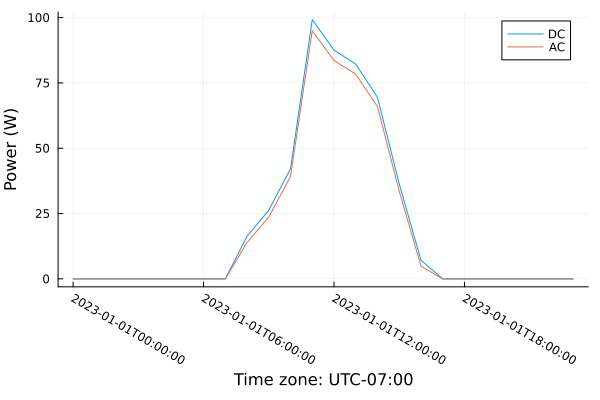

In [33]:
# docs example

latitude = 35.1
longitude = -106.6
altitude = 1500.0 # m
start_date = Date(2023, 1, 1)
end_date = Date(2023, 1, 1)
tz = TimeZone("America/Denver")

# Usually, use `get_meteorological_data_pvgis`. For building focs, a local file is used with example PVGIS data.
# weather_data = get_meteorological_data_pvgis(latitude, longitude, start_date, end_date, tz, false);
weather_data_txt = read("../data/weather_data.json", String)
weather_rows = JSON.parse(weather_data_txt)
weather_data = [
    WeatherSample(
        ZonedDateTime(r["time"]),
        isnothing(r["ghi"]) ? missing : r["ghi"],
        isnothing(r["dni"]) ? missing : r["dni"],
        isnothing(r["dhi"]) ? missing : r["dhi"],
        isnothing(r["temp_air"]) ? missing : r["temp_air"],
        isnothing(r["temp_dew"]) ? missing : r["temp_dew"],
        isnothing(r["relative_humidity"]) ? missing : r["relative_humidity"],
        isnothing(r["pressure"]) ? missing : r["pressure"],
        isnothing(r["wind_speed"]) ? missing : r["wind_speed"],
        isnothing(r["wind_direction"]) ? missing : r["wind_direction"],
        isnothing(r["albedo"]) ? missing : r["albedo"],
    )
    for r in weather_rows
]

solar_position = get_solar_position(latitude, longitude, altitude, weather_data)

surface_tilt = latitude
surface_azimuth = 180.0
total_irradiance = get_total_irradiance(surface_tilt, surface_azimuth, weather_data, solar_position, 0.25)

module_filename = "sam-library-sandia-modules-2015-6-30.csv"
module_name = "Canadian Solar CS5P-220M [ 2009]"
pv_module = read_solar_module(module_name, module_filename)

inverter_filename = "sam-library-cec-inverters-2019-03-05.csv"
inverter_name = "ABB: MICRO-0.25-I-OUTD-US-208 [208V]"
pv_inverter = read_solar_inverter(inverter_name, inverter_filename)

cell_temp = sapm_cell_temperature(total_irradiance, weather_data)

effective_irradiance = sapm_effective_irradiance(
    total_irradiance, pv_module, solar_position, surface_tilt, surface_azimuth, altitude
)

dc_components = sapm_dc_components(pv_module, effective_irradiance, cell_temp)
ac_power = sandia_ac_power(pv_inverter, dc_components)

plot(
    getfield.(dc_components, :time), 
    getfield.(dc_components, :p_mp),
    label="DC",
    xlabel="Time",
    ylabel="Power (W)",
    legend=:topright,
    xrotation=-30,
    bottom_margin=8Plots.mm,
)
plot!(getfield.(ac_power, :time), getfield.(ac_power, :ac_power); label="AC")

